In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
ls /content/drive/MyDrive/datasets


LLVIP/  LLVIP.zip  LYNRED_multimodal_detection_V1.zip  MFNET/  MFNET.gz


In [ ]:
!unzip -q /content/drive/MyDrive/datasets/LLVIP.zip -d /content


## Imports


Imports and Dependencies

This section loads all required libraries for:
- Data processing (NumPy, OpenCV)
- Visualization (Matplotlib)
- Deep learning (PyTorch, timm)
- Dataset handling
- Wavelet transforms (DWT)

In [ ]:
# Install dependencies
!pip install torch torchvision pytorch_wavelets timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.0 MB/s eta 0:00:00


In [ ]:
# Standard Library Imports
import os
import random
import shutil
import zipfile
import warnings
import logging
import xml.etree.ElementTree as ET

# Third-Party Imports
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import matplotlib.patches as patches


# PyTorch Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.ops as ops
from torch.cuda.amp import autocast, GradScaler

# External ML Libraries
import timm
from pycocotools.coco import COCO
from pytorch_wavelets import DWTForward


## LLVIP Dataset

In [ ]:
ls /content

drive/  LLVIP/  sample_data/


In [ ]:
LLVIP_dataset_root = "/content/LLVIP/"

In [ ]:
class LLVIPDataset(Dataset):

    def __init__(self, root_dir, split="train"):

        self.root_dir = root_dir
        self.split = split

        self.rgb_dir = os.path.join(
            root_dir,
            "visible",
            split
        )

        self.ir_dir = os.path.join(
            root_dir,
            "infrared",
            split
        )

        self.ann_dir = os.path.join(
            root_dir,
            "Annotations"
        )

        self.image_ids = sorted(
            f.split(".")[0]
            for f in os.listdir(self.rgb_dir)
        )

    def __len__(self):
        return len(self.image_ids)

    def parse_voc(self, xml_path):

        boxes = []

        if not os.path.exists(xml_path):
            return boxes

        tree = ET.parse(xml_path)
        root = tree.getroot()

        for obj in root.findall("object"):

            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            if xmax <= xmin or ymax <= ymin:
                continue

            boxes.append([
                xmin,
                ymin,
                xmax,
                ymax
            ])

        return boxes

    def __getitem__(self, idx):

        image_id = self.image_ids[idx]

        rgb_path = os.path.join(
            self.rgb_dir,
            image_id + ".jpg"
        )

        ir_path = os.path.join(
            self.ir_dir,
            image_id + ".jpg"
        )

        xml_path = os.path.join(
            self.ann_dir,
            image_id + ".xml"
        )

        # ==================================
        # LOAD RGB
        # ==================================
        rgb = cv2.imread(rgb_path)

        if rgb is None:
            raise FileNotFoundError(rgb_path)

        rgb = cv2.cvtColor(
            rgb,
            cv2.COLOR_BGR2RGB
        )

        # ORIGINAL SIZE
        orig_h, orig_w = rgb.shape[:2]

        # ==================================
        # LOAD IR
        # ==================================
        ir = cv2.imread(
            ir_path,
            cv2.IMREAD_GRAYSCALE
        )

        if ir is None:
            raise FileNotFoundError(ir_path)

        # ==================================
        # LOAD BOXES
        # ==================================
        boxes = self.parse_voc(xml_path)

        yolo_boxes = []

        for xmin, ymin, xmax, ymax in boxes:

            xc = ((xmin + xmax) * 0.5) / orig_w
            yc = ((ymin + ymax) * 0.5) / orig_h

            bw = (xmax - xmin) / orig_w
            bh = (ymax - ymin) / orig_h

            xc = np.clip(xc, 0.0, 1.0)
            yc = np.clip(yc, 0.0, 1.0)

            bw = np.clip(bw, 0.0, 1.0)
            bh = np.clip(bh, 0.0, 1.0)

            yolo_boxes.append([
                0,      # person class
                xc,
                yc,
                bw,
                bh
            ])

        # ==================================
        # RESIZE IMAGES
        # ==================================
        size = 640

        rgb = cv2.resize(
            rgb,
            (size, size),
            interpolation=cv2.INTER_LINEAR
        )

        ir = cv2.resize(
            ir,
            (size, size),
            interpolation=cv2.INTER_LINEAR
        )

        # ==================================
        # TO TENSOR
        # ==================================
        rgb = (
            torch.from_numpy(rgb)
            .permute(2, 0, 1)
            .float()
            / 255.0
        )

        ir = (
            torch.from_numpy(ir)
            .unsqueeze(0)
            .float()
            / 255.0
        )

        if len(yolo_boxes):

            yolo_boxes = torch.tensor(
                yolo_boxes,
                dtype=torch.float32
            )

        else:

            yolo_boxes = torch.zeros(
                (0, 5),
                dtype=torch.float32
            )

        return rgb, ir, yolo_boxes

In [ ]:
def collate_fn(batch):
    # remove broken samples
    batch = [b for b in batch if b is not None]

    if len(batch) == 0:
        return None

    rgbs, irs, targets = zip(*batch)

    rgbs = torch.stack(rgbs)
    irs  = torch.stack(irs)

    return rgbs, irs, list(targets)

## Model

In [ ]:
class Backbone(nn.Module):
    def __init__(self, in_ch=3, model_name="mobilenetv3_large_100", out_ch=256):
        super().__init__()

        self.model = timm.create_model(
            model_name,
            pretrained=True,
            features_only=True,
            out_indices=(2, 3, 4),  # stable pyramid levels
            in_chans=in_ch
        )

        self.channels = self.model.feature_info.channels()
        selected_channels = self.channels  # filtered by out_indices

        # unify channels
        self.proj = nn.ModuleList([
            nn.Conv2d(c, out_ch, 1) for c in selected_channels
        ])

        # refinement (adds depth)
        self.refine = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.SiLU(inplace=True),

                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.SiLU(inplace=True),
            )
            for _ in selected_channels
        ])

    def forward(self, x):
      feats = self.model(x)  # [P3, P4, P5]

      out = []
      for i, f in enumerate(feats):
          f = self.proj[i](f)
          f = self.refine[i](f)
          out.append(f)

      return out

In [ ]:
class ScalarConfidenceGate(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(c, c // 2, 1),
            nn.SiLU(inplace=True),
            nn.Conv2d(c // 2, c, 1)   # per-channel gating
        )

    def forward(self, x):
        w = torch.sigmoid(self.net(x))  # [0, 1]

        # residual-style gating (more stable)
        return x * (0.5 + w)   # range [0.5, 1.5]

In [ ]:
class SafeResidualFusion(nn.Module):
    def __init__(self, c):
        super().__init__()

        self.refine = nn.Sequential(
            nn.Conv2d(c * 2, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),

            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )

        # learnable fusion weight
        self.alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, base, new):
        fused = self.refine(torch.cat([base, new], dim=1))

        # table residual fusion
        return base + torch.sigmoid(self.alpha) * fused

## Wawelet Transformation and IR Component Specific Classes

In [ ]:
class WaveletDecompose(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.dwt = DWTForward(J=1, wave='haar')

        # learnable scaling
        self.low_proj = nn.Conv2d(c, c, 1)
        self.high_proj = nn.Conv2d(c * 3, c, 1)

    def forward(self, x):
        yl, yh = self.dwt(x)
        yh = yh[0]  # (B, C, 3, H/2, W/2)

        yh = yh.view(x.size(0), -1, yl.size(2), yl.size(3))

        # normalize and project
        yl = self.low_proj(yl)
        yh = self.high_proj(yh)

        return yl, yh

In [ ]:
class FrequencyMixer(nn.Module):
    def __init__(self, c):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Conv2d(c * 2, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
            nn.Conv2d(c, c, 1),
            nn.Sigmoid()
        )

        self.refine = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True)
        )

    def forward(self, low, high):
        w = self.gate(torch.cat([low, high], dim=1))

        fused = w * low + (1 - w) * high

        return fused + self.refine(fused)  # residual boost

In [ ]:
class EdgeEnhance(nn.Module):
    def __init__(self, c):
        super().__init__()

        # Sobel kernels
        kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32)
        ky = kx.t()

        self.register_buffer("kx", kx.view(1,1,3,3))
        self.register_buffer("ky", ky.view(1,1,3,3))

        # projection
        self.proj = nn.Conv2d(1, c, 1)

        # normalization
        self.bn = nn.BatchNorm2d(c)

        # learnable strength
        self.alpha = nn.Parameter(torch.tensor(0.2))

    def forward(self, ir):
        if ir is None:
            return None

        # Sobel gradients
        gx = F.conv2d(ir, self.kx, padding=1)
        gy = F.conv2d(ir, self.ky, padding=1)

        # magnitude
        edge = torch.sqrt(gx**2 + gy**2 + 1e-6)

        # normalize
        edge = edge / (edge.mean(dim=[2,3], keepdim=True) + 1e-6)

        # project to feature space
        edge = self.proj(edge)
        edge = self.bn(edge)

        # controlled scaling instead of tanh
        return torch.sigmoid(self.alpha) * edge

In [ ]:
class SpatialPoolingAttention(nn.Module):
    def __init__(self, c):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, c // 4, 3, padding=1),   # now 4 channels input
            nn.BatchNorm2d(c // 4),
            nn.SiLU(inplace=True),

            nn.Conv2d(c // 4, 1, 1)
        )

    def forward(self, x):

        B, C, H, W = x.shape

        # =====================
        # STANDARD POOLING
        # =====================
        avg = torch.mean(x, dim=1, keepdim=True)

        mx, _ = torch.max(
            x,
            dim=1,
            keepdim=True
        )

        # =====================
        # DIRECTIONAL FEATURES
        # =====================

        # horizontal
        gx = torch.mean(
            x,
            dim=1,
            keepdim=True
        )  # [B,1,H,W]

        gx = torch.mean(
            gx,
            dim=2,
            keepdim=True
        )  # [B,1,1,W]

        gx = gx.expand(-1, -1, H, W)

        # vertical
        gy = torch.mean(
            x,
            dim=1,
            keepdim=True
        )  # [B,1,H,W]

        gy = torch.mean(
            gy,
            dim=3,
            keepdim=True
        )  # [B,1,H,1]

        gy = gy.expand(-1, -1, H, W)

        # =====================
        # ATTENTION
        # =====================
        attn = torch.cat(
            [avg, mx, gx, gy],
            dim=1
        )

        attn = torch.sigmoid(
            self.conv(attn)
        )

        return x * (0.5 + attn)

In [ ]:
class FusionBlock(nn.Module):
    def __init__(self, c, use_ir=False, use_wavelet=False):
        super().__init__()

        self.use_ir = use_ir
        self.use_wavelet = use_wavelet

        # CORE
        self.conf = ScalarConfidenceGate(c)
        self.safe = SafeResidualFusion(c)
        self.spatial = SpatialPoolingAttention(c)

        # IR
        self.edge = EdgeEnhance(c)
        self.ir_proj = nn.Conv2d(1, c, 1)

        # adaptive IR gating
        self.ir_gate = nn.Sequential(
            nn.Conv2d(c * 2, c, 1),
            nn.Sigmoid()
        )

        #  WAVELET
        if self.use_wavelet:
            self.wave = WaveletDecompose(c)
            self.freq_mixer = FrequencyMixer(c)

    def forward(self, rgb, ir=None):
        # RGB BASE
        rgb = self.conf(rgb)
        fused = rgb


        # IR FUSION
        if self.use_ir and ir is not None:

            ir_resized = F.interpolate(
                ir, size=rgb.shape[-2:], mode='bilinear', align_corners=False
            )

            ir_feat = self.ir_proj(ir_resized)

            # main fusion (residual)
            fused = self.safe(fused, ir_feat)

            # EDGE GUIDANCE
            edge = self.edge(ir)
            if edge is not None:
                edge = F.interpolate(
                    edge, size=fused.shape[-2:], mode='bilinear', align_corners=False
                )

                # gated edge fusion
                w = self.ir_gate(torch.cat([fused, edge], dim=1))
                fused = fused * (1 - w) + edge * w

        # WAVELET (OPTIONAL)
        if self.use_wavelet and self.use_ir and ir is not None:

            r_low, r_high = self.wave(rgb)
            i_low, i_high = self.wave(ir)

            freq = self.freq_mixer(r_low + i_low, r_high + i_high)

            freq = F.interpolate(
                freq, size=fused.shape[-2:], mode='bilinear', align_corners=False
            )

            fused = fused + 0.1 * freq  # light residual

        # SPATIAL ATTENTION
        fused = self.spatial(fused)

        return fused

In [ ]:
class FusionBackbone(nn.Module):
    def __init__(self, use_ir=False, out_ch=256):
        super().__init__()

        self.use_ir = use_ir
        self.out_ch = out_ch

        # RGB backbone
        self.rgb = Backbone(in_ch=3, out_ch=out_ch)

        # now channels are FIXED
        ch = [out_ch, out_ch, out_ch]

        # fusion blocks
        self.fusion = nn.ModuleList([
            FusionBlock(c, use_ir=use_ir) for c in ch
        ])

        # IR pyramid (scale-aware)
        if use_ir:
            self.ir_downsample = nn.ModuleList([
                nn.Identity(),                 # P3
                nn.AvgPool2d(2),              # P4
                nn.AvgPool2d(4)               # P5
            ])

    def forward(self, rgb, ir=None):
        # RGB FEATURES
        rgb_feats = self.rgb(rgb)   # [P3, P4, P5]

        # RGB-ONLY MODE
        if not self.use_ir or ir is None:
            return rgb_feats


        # IR PREP (multi-scale)
        ir_feats = []
        for i in range(len(rgb_feats)):
            ir_scaled = self.ir_downsample[i](ir)
            ir_feats.append(ir_scaled)

        # FUSION
        fused = []
        for i in range(len(rgb_feats)):
            f = self.fusion[i](rgb_feats[i], ir_feats[i])
            fused.append(f)

        return fused

In [ ]:
class SimpleFPN(nn.Module):
    def __init__(self, c=256):
        super().__init__()

        # TOP-DOWN
        self.lat5 = nn.Conv2d(c, c, 1)
        self.lat4 = nn.Conv2d(c, c, 1)

        self.smooth4 = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )

        self.smooth3 = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )

        # BOTTOM-UP (PAN)
        self.down3 = nn.Conv2d(c, c, 3, stride=2, padding=1)
        self.down4 = nn.Conv2d(c, c, 3, stride=2, padding=1)

        self.out4 = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )

        self.out5 = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1),
            nn.BatchNorm2d(c),
            nn.SiLU(inplace=True),
        )

    def forward(self, feats):
        c3, c4, c5 = feats

        # TOP-DOWN
        p5 = c5

        p4 = c4 + F.interpolate(self.lat5(c5), scale_factor=2, mode="nearest")
        p4 = self.smooth4(p4)

        p3 = c3 + F.interpolate(self.lat4(p4), scale_factor=2, mode="nearest")
        p3 = self.smooth3(p3)

        # BOTTOM-UP
        p4 = p4 + self.down3(p3)
        p4 = self.out4(p4)

        p5 = p5 + self.down4(p4)
        p5 = self.out5(p5)

        return [p3, p4, p5]

In [ ]:
class YOLOHeadDFL(nn.Module):
    def __init__(self, channels, num_classes=1, reg_max=16):
        super().__init__()

        self.num_classes = num_classes
        self.reg_max = reg_max

        self.heads = nn.ModuleList([
            self._build_head(c) for c in channels
        ])

    def _build_head(self, c):
        return nn.ModuleDict({

            "stem": nn.Sequential(
                nn.Conv2d(c, c, 3, padding=1),
                nn.BatchNorm2d(c),
                nn.SiLU(inplace=True),

                nn.Conv2d(c, c, 3, padding=1),
                nn.BatchNorm2d(c),
                nn.SiLU(inplace=True),
            ),

            # DFL box: 4 * reg_max
            "box": nn.Conv2d(c, 4 * self.reg_max, 1),

            "obj": nn.Conv2d(c, 1, 1),
            "cls": nn.Conv2d(c, self.num_classes, 1),
        })

    def forward(self, feats):
        outs = []

        for head, x in zip(self.heads, feats):
            x = head["stem"](x)

            box = head["box"](x)   # [B, 4*reg_max, H, W]
            obj = head["obj"](x)
            cls = head["cls"](x)

            out = torch.cat([box, obj, cls], dim=1)
            outs.append(out)

        return outs

In [ ]:
class FullModel(nn.Module):
    def __init__(self, num_classes=1, use_ir=False):
        super().__init__()

        self.use_ir = use_ir

        # backbone
        self.backbone = FusionBackbone(use_ir=use_ir)

        self.out_ch = 256

        # FPN
        self.fpn = SimpleFPN(self.out_ch)

        # head (must match FPN!)
        self.detector = YOLOHeadDFL([self.out_ch] * 3, num_classes)

    def forward(self, rgb, ir=None):

        feats = self.backbone(rgb, ir)   # → [256,256,256]

        feats = self.fpn(feats)          # → [256,256,256]

        preds = self.detector(feats)

        return preds

In [ ]:
model = FullModel()

rgb = torch.randn(2,3,256,256)
ir = torch.randn(2,1,256,256)

out = model(rgb,ir)

for o in out:
    print(o.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

torch.Size([2, 66, 32, 32])
torch.Size([2, 66, 16, 16])
torch.Size([2, 66, 8, 8])


## Train Utils

In [ ]:
def bbox_ciou_batch(box1, box2):
    b1_x1 = box1[:, 0] - box1[:, 2] / 2
    b1_y1 = box1[:, 1] - box1[:, 3] / 2
    b1_x2 = box1[:, 0] + box1[:, 2] / 2
    b1_y2 = box1[:, 1] + box1[:, 3] / 2

    b2_x1 = box2[:, 0] - box2[:, 2] / 2
    b2_y1 = box2[:, 1] - box2[:, 3] / 2
    b2_x2 = box2[:, 0] + box2[:, 2] / 2
    b2_y2 = box2[:, 1] + box2[:, 3] / 2

    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)

    inter = (inter_x2 - inter_x1).clamp(min=0) * \
            (inter_y2 - inter_y1).clamp(min=0)

    area1 = (b1_x2 - b1_x1).clamp(min=1e-6) * (b1_y2 - b1_y1).clamp(min=1e-6)
    area2 = (b2_x2 - b2_x1).clamp(min=1e-6) * (b2_y2 - b2_y1).clamp(min=1e-6)

    union = area1 + area2 - inter + 1e-6
    iou = inter / union

    center_dist = (box1[:, 0] - box2[:, 0])**2 + (box1[:, 1] - box2[:, 1])**2

    enc_x1 = torch.min(b1_x1, b2_x1)
    enc_y1 = torch.min(b1_y1, b2_y1)
    enc_x2 = torch.max(b1_x2, b2_x2)
    enc_y2 = torch.max(b1_y2, b2_y2)

    enc_diag = (enc_x2 - enc_x1)**2 + (enc_y2 - enc_y1)**2 + 1e-6

    v = (4 / (3.14159265**2)) * torch.pow(
        torch.atan(box1[:, 2] / (box1[:, 3] + 1e-6)) -
        torch.atan(box2[:, 2] / (box2[:, 3] + 1e-6)), 2
    )

    alpha = v / (1 - iou + v + 1e-6)

    ciou = iou - (center_dist / enc_diag) - alpha * v

    return torch.clamp(ciou, -1.0, 1.0)

In [ ]:
# GRID
def make_grid(H, W, device):
    y, x = torch.meshgrid(
        torch.arange(H, device=device),
        torch.arange(W, device=device),
        indexing='ij'
    )
    return x.reshape(-1), y.reshape(-1)  # [HW]


In [ ]:
# DFL DECODE (ALL PIXELS)
def dfl_decode_all(box_pred, reg_max):
    B, _, H, W = box_pred.shape

    box_pred = box_pred.view(B, 4, reg_max, H, W)
    box_pred = torch.softmax(box_pred, dim=2)

    proj = torch.arange(reg_max, device=box_pred.device).float()
    dist = (box_pred * proj.view(1,1,-1,1,1)).sum(dim=2)

    return dist  # [B,4,H,W]

In [ ]:
# LTRB → XYWH (ALL)
def ltrb_to_xywh_all(dist, H, W):
    B = dist.shape[0]
    device = dist.device

    x, y = torch.meshgrid(
        torch.arange(W, device=device),
        torch.arange(H, device=device),
        indexing='xy'
    )

    cx = (x + 0.5) / W
    cy = (y + 0.5) / H

    cx = cx.unsqueeze(0)
    cy = cy.unsqueeze(0)

    l, t, r, b = dist[:,0], dist[:,1], dist[:,2], dist[:,3]

    x1 = cx - l / W
    y1 = cy - t / H
    x2 = cx + r / W
    y2 = cy + b / H

    w = x2 - x1
    h = y2 - y1
    xc = x1 + w / 2
    yc = y1 + h / 2

    return torch.stack([xc, yc, w, h], dim=1)  # [B,4,H,W]

In [ ]:
# DFL LOSS (VECTOR)
def dfl_loss(pred, target, reg_max):
    pred = pred.view(-1, reg_max)
    target = target.clamp(0, reg_max - 1 - 1e-3)

    left = target.long()
    right = left + 1

    wl = right.float() - target
    wr = 1 - wl

    logp = F.log_softmax(pred, dim=1)

    loss = (
        -logp[torch.arange(len(left)), left] * wl
        -logp[torch.arange(len(left)), right] * wr
    )

    return loss.mean()

In [ ]:
# MAIN LOSS (YOLOv8-STYLE)
def detection_loss_yolov8(preds, targets):

    reg_max = 16

    total_box = 0
    total_obj = 0
    total_cls = 0
    total_dfl = 0

    for p in preds:

        B, _, H, W = p.shape
        HW = H * W

        box_pred = p[:, :4 * reg_max]
        obj_pred = p[:, 4 * reg_max:4 * reg_max + 1]
        cls_pred = p[:, 4 * reg_max + 1:]

        # decode ALL predictions once
        dist = dfl_decode_all(box_pred, reg_max)
        pred_boxes = ltrb_to_xywh_all(dist, H, W)  # [B,4,H,W]

        obj_target = torch.zeros_like(obj_pred)
        cls_target = torch.zeros_like(cls_pred)

        x_idx, y_idx = make_grid(H, W, p.device)

        for b in range(B):

            if len(targets[b]) == 0:
                continue

            pred_boxes_flat = pred_boxes[b].view(4, -1).permute(1,0)  # [HW,4]
            cls_flat = cls_pred[b].view(cls_pred.shape[1], -1)

            gt = targets[b]  # [N,5]

            gt_boxes = gt[:, 1:]
            gt_cls = gt[:, 0].long()


            # COST MATRIX (vectorized)
            num_gt = gt_boxes.shape[0]

            pred_boxes_exp = pred_boxes_flat.unsqueeze(0).repeat(num_gt,1,1)
            gt_boxes_exp = gt_boxes.unsqueeze(1).repeat(1,HW,1)

            ciou = bbox_ciou_batch(
                pred_boxes_exp.reshape(-1,4),
                gt_boxes_exp.reshape(-1,4)
            ).view(num_gt, HW)

            iou_loss = 1 - ciou

            cls_scores = cls_flat[gt_cls]  # [num_gt, HW]
            cls_loss = F.binary_cross_entropy_with_logits(
                cls_scores, torch.ones_like(cls_scores)
            )

            cost = iou_loss + 0.5 * cls_loss

            # =====================
            # DYNAMIC K MATCHING
            # =====================
            matching = torch.zeros_like(cost)

            for i in range(num_gt):
                topk = min(20, HW)  # increased candidate pool

                topk_iou = torch.topk(ciou[i], topk).values

                # stronger dynamic K
                k = int(topk_iou.sum().item() * 1.5)
                k = max(3, min(k, 30))  # clamp

                # use cost (not only IoU)
                _, idx = torch.topk(cost[i], k, largest=False)

                matching[i, idx] = 1.0

            # resolve conflicts
            anchor_match = matching.sum(0)
            if (anchor_match > 1).any():
                min_cost_idx = cost[:, anchor_match > 1].argmin(0)
                matching[:, anchor_match > 1] *= 0
                matching[min_cost_idx, anchor_match > 1] = 1

            # =====================
            # BUILD TARGETS
            # =====================
            pos_idx = matching.sum(0) > 0

            obj_target[b, 0].view(-1)[pos_idx] = 1.0

            matched_gt = matching[:, pos_idx].argmax(0)

            cls_target_flat = cls_target[b].view(cls_pred.shape[1], -1)

            cls_target_flat[:, pos_idx] = 0
            cls_target_flat[gt_cls[matched_gt], pos_idx] = 1
            # =====================
            # BOX LOSS
            # =====================
            pos_boxes = pred_boxes_flat[pos_idx]
            target_boxes = gt_boxes[matched_gt]

            ciou_pos = bbox_ciou_batch(pos_boxes, target_boxes)

            total_box += (1 - ciou_pos).mean()

            # =====================
            # DFL LOSS (vectorized)
            # =====================
            pos_indices = pos_idx.nonzero().squeeze(1)

            pred_dist = box_pred[b].view(4, reg_max, H, W)
            pred_dist = pred_dist.permute(2,3,0,1).reshape(-1,4,reg_max)

            pred_dist_pos = pred_dist[pos_indices]

            # convert GT → ltrb
            cx = (x_idx[pos_indices] + 0.5) / W
            cy = (y_idx[pos_indices] + 0.5) / H

            x1 = target_boxes[:,0] - target_boxes[:,2]/2
            y1 = target_boxes[:,1] - target_boxes[:,3]/2
            x2 = target_boxes[:,0] + target_boxes[:,2]/2
            y2 = target_boxes[:,1] + target_boxes[:,3]/2

            l = (cx - x1) * W
            t = (cy - y1) * H
            r = (x2 - cx) * W
            b = (y2 - cy) * H

            target_ltrb = torch.stack([l,t,r,b], dim=1)

            total_dfl += dfl_loss(
                pred_dist_pos.reshape(-1, reg_max),
                target_ltrb.reshape(-1),
                reg_max
            )

        total_obj += F.binary_cross_entropy_with_logits(obj_pred, obj_target)
        total_cls += F.binary_cross_entropy_with_logits(cls_pred, cls_target)

    total_loss = (
      2.5 * total_box +
      1.0 * total_obj +
      0.5 * total_cls +
      1.0 * total_dfl
    )

    return total_loss, total_box, total_obj

In [ ]:
# =====================
# EMA
# =====================
class ModelEMA:
    def __init__(self, model, decay=0.9998):
        self.ema = type(model)(num_classes=1, use_ir=False).to(device)
        self.ema.load_state_dict(model.state_dict())
        self.ema.eval()

        self.decay = decay
        self.updates = 0

        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        self.updates += 1
        d = self.decay * (1 - torch.exp(torch.tensor(-self.updates / 2000.0)))

        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(d).add_(msd[k].detach(), alpha=1 - d)

## Train Loop

In [ ]:
root_dir = "/content/LLVIP"

from torch.utils.data import random_split

full_train = LLVIPDataset(
    root_dir=root_dir,
    split="train"
)

train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size

train_dataset, val_dataset = random_split(
    full_train,
    [train_size, val_size]
)

test_dataset = LLVIPDataset(
    root_dir=root_dir,
    split="test"
)

In [ ]:
NUM_WORKERS = min(8, os.cpu_count())

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True,

    prefetch_factor=4,

    collate_fn=collate_fn,

    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True,

    prefetch_factor=4,

    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True,

    prefetch_factor=4,

    collate_fn=collate_fn
)

In [ ]:
!pip install torchmetrics

from torchmetrics.detection.mean_ap import MeanAveragePrecision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.6 MB/s eta 0:00:00


In [ ]:
def decode_predictions(
    preds,
    reg_max=16,
    conf_thres=0.3
):

    all_boxes = []

    for p in preds:

        B, _, H, W = p.shape

        p = p[0]

        # =====================
        # SPLIT
        # =====================
        box_pred = p[:4 * reg_max]

        obj_pred = p[4 * reg_max]

        # =====================
        # DFL DECODE
        # =====================
        box_pred = box_pred.view(
            4,
            reg_max,
            H,
            W
        )

        prob = torch.softmax(
            box_pred,
            dim=1
        )

        proj = torch.arange(
            reg_max,
            device=p.device,
            dtype=torch.float32
        ).view(1, reg_max, 1, 1)

        dist = (prob * proj).sum(dim=1)

        # =====================
        # GRID
        # =====================
        y, x = torch.meshgrid(
            torch.arange(H, device=p.device),
            torch.arange(W, device=p.device),
            indexing='ij'
        )

        cx = (x + 0.5) / W
        cy = (y + 0.5) / H

        l, t, r, b = dist

        x1 = cx - l / W
        y1 = cy - t / H
        x2 = cx + r / W
        y2 = cy + b / H

        w = x2 - x1
        h = y2 - y1

        xc = x1 + w / 2
        yc = y1 + h / 2

        obj = torch.sigmoid(obj_pred)

        # =====================
        # FILTER
        # =====================
        mask = obj > conf_thres

        if mask.sum() == 0:
            continue

        boxes = torch.stack([
            xc[mask],
            yc[mask],
            w[mask],
            h[mask],
            obj[mask]
        ], dim=1)

        all_boxes.append(boxes)

    if len(all_boxes) == 0:

        return torch.empty(
            (0,5),
            device=preds[0].device
        )

    return torch.cat(all_boxes, dim=0)

In [ ]:
def apply_nms(
    boxes,
    conf_thres=0.3,
    iou_thres=0.5
):

    if boxes.numel() == 0:
        return boxes

    scores = boxes[:,4]

    mask = scores > conf_thres

    boxes = boxes[mask]

    if boxes.shape[0] == 0:
        return boxes

    # XYWH -> XYXY
    xc = boxes[:,0]
    yc = boxes[:,1]
    bw = boxes[:,2]
    bh = boxes[:,3]

    x1 = xc - bw/2
    y1 = yc - bh/2
    x2 = xc + bw/2
    y2 = yc + bh/2

    xyxy = torch.stack(
        [x1, y1, x2, y2],
        dim=1
    )

    keep = ops.nms(
        xyxy,
        boxes[:,4],
        iou_thres
    )

    return boxes[keep]

In [ ]:
def preds_to_map_format(
    preds,
    reg_max=16,
    conf_thres=0.3,
    iou_thres=0.5
):

    batch_size = preds[0].shape[0]

    all_preds = []


    # PROCESS EACH IMAGE SEPARATELY
    for b in range(batch_size):

        image_boxes = []

        # EACH FEATURE LEVEL
        for p in preds:

            # p -> [B,C,H,W]

            single = p[b:b+1]

            boxes = decode_predictions(
                [single],
                reg_max=reg_max,
                conf_thres=conf_thres
            )

            if boxes.numel() > 0:
                image_boxes.append(boxes)

        # NO DETECTIONS
        if len(image_boxes) == 0:

            all_preds.append({
                "boxes": torch.empty((0,4)),
                "scores": torch.empty((0,)),
                "labels": torch.empty(
                    (0,),
                    dtype=torch.int64
                )
            })

            continue

        # CONCAT LEVELS
        image_boxes = torch.cat(
            image_boxes,
            dim=0
        )

        # NMS
        image_boxes = apply_nms(
            image_boxes,
            conf_thres,
            iou_thres
        )


        # STILL EMPTY
        if image_boxes.numel() == 0:

            all_preds.append({
                "boxes": torch.empty((0,4)),
                "scores": torch.empty((0,)),
                "labels": torch.empty(
                    (0,),
                    dtype=torch.int64
                )
            })

            continue

        # XYWH -> XYXY
        xc = image_boxes[:,0]
        yc = image_boxes[:,1]
        bw = image_boxes[:,2]
        bh = image_boxes[:,3]

        x1 = xc - bw / 2
        y1 = yc - bh / 2
        x2 = xc + bw / 2
        y2 = yc + bh / 2

        xyxy = torch.stack(
            [x1, y1, x2, y2],
            dim=1
        )

        scores = image_boxes[:,4]

        labels = torch.zeros(
            len(image_boxes),
            dtype=torch.int64,
            device=image_boxes.device
        )

        all_preds.append({
            "boxes": xyxy.detach().cpu(),
            "scores": scores.detach().cpu(),
            "labels": labels.detach().cpu()
        })

    return all_preds

In [ ]:
def targets_to_map_format(targets):

    all_targets = []

    for gt in targets:

        if len(gt) == 0:

            all_targets.append({
                "boxes": torch.empty((0,4)),
                "labels": torch.empty(
                    (0,),
                    dtype=torch.int64
                )
            })

            continue

        xc = gt[:,1]
        yc = gt[:,2]
        bw = gt[:,3]
        bh = gt[:,4]

        x1 = xc - bw/2
        y1 = yc - bh/2
        x2 = xc + bw/2
        y2 = yc + bh/2

        xyxy = torch.stack(
            [x1, y1, x2, y2],
            dim=1
        )

        labels = gt[:,0].long()

        all_targets.append({
            "boxes": xyxy.detach().cpu(),
            "labels": labels.detach().cpu()
        })

    return all_targets

In [ ]:
# SETUP
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True

model = FullModel(
    num_classes=1,
    use_ir=True
).to(device)

# LOAD RGB PRETRAIN
ckpt = torch.load(
    "/content/best_rgb_model.pth",
    map_location=device
)

model.load_state_dict(
    ckpt["model_state_dict"],
    strict=False
)

print("✅ RGB pretrained weights loaded")

# FREEZE RGB BACKBONE
FREEZE_EPOCHS = 10

for p in model.backbone.rgb.parameters():
    p.requires_grad = False

print("🔒 RGB backbone frozen")

# OPTIMIZER
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scaler = torch.amp.GradScaler("cuda")

epochs = 60

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-4,
    total_steps=epochs * len(train_loader),
    pct_start=0.1
)

# EMA
ema = ModelEMA(model)

ema.ema.load_state_dict(
    model.state_dict(),
    strict=False
)

# METRICS
metric = MeanAveragePrecision()

# HISTORY
train_losses = []
val_losses = []

val_map50s = []
val_map5095s = []

val_precisions = []
val_recalls = []

best_map50 = 0.0

os.makedirs("checkpoints", exist_ok=True)

# TRAIN LOOP
for epoch in range(epochs):


    # UNFREEZE
    if epoch == FREEZE_EPOCHS:

        print("🔓 Unfreezing RGB backbone...")

        for p in model.backbone.rgb.parameters():
            p.requires_grad = True


    # TRAIN
    model.train()

    train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{epochs} [TRAIN]"
    )

    for step, batch in enumerate(train_bar):

        if batch is None:
            continue

        rgb, ir, targets = batch

        rgb = rgb.to(device, non_blocking=True)
        ir  = ir.to(device, non_blocking=True)

        targets = [t.to(device) for t in targets]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            "cuda",
            enabled=(device == "cuda")
        ):

            preds = model(rgb, ir)

            loss, box_loss, obj_loss = detection_loss_yolov8(
                preds,
                targets
            )

        if not torch.isfinite(loss):
            print("⚠️ Skipping bad batch")
            continue

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        ema.update(model)

        train_loss += loss.item()

        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "box": f"{box_loss.item():.4f}",
            "obj": f"{obj_loss.item():.4f}",
            "avg": f"{train_loss/(step+1):.4f}",
            "lr": f"{optimizer.param_groups[0]['lr']:.6f}"
        })

    train_loss /= max(1, len(train_loader))

    # VALIDATION
    ema.ema.eval()

    val_loss = 0.0

    metric.reset()

    val_bar = tqdm(
        val_loader,
        desc=f"Epoch {epoch+1}/{epochs} [VAL]"
    )

    with torch.no_grad():

        for step, batch in enumerate(val_bar):

            if batch is None:
                continue

            rgb, ir, targets = batch

            rgb = rgb.to(device, non_blocking=True)
            ir  = ir.to(device, non_blocking=True)

            targets = [t.to(device) for t in targets]

            with torch.amp.autocast(
                "cuda",
                enabled=(device == "cuda")
            ):

                preds = ema.ema(rgb, ir)

                loss, _, _ = detection_loss_yolov8(
                    preds,
                    targets
                )

            if not torch.isfinite(loss):
                continue

            val_loss += loss.item()

            # REAL mAP UPDATE
            metric_preds = preds_to_map_format(preds)

            metric_targets = targets_to_map_format(targets)

            metric.update(
                metric_preds,
                metric_targets
            )


    # FINAL METRICS
    metrics = metric.compute()

    val_map50 = metrics["map_50"].item()
    val_map5095 = metrics["map"].item()
    val_precision = metrics["mar_100"].item()

    val_loss /= max(1, len(val_loader))

    # HISTORY
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    val_map50s.append(val_map50)
    val_map5095s.append(val_map5095)

    val_precisions.append(val_precision)

    # REPORT
    print(
        f"\nEpoch {epoch+1} | "
        f"Train={train_loss:.4f} | "
        f"Val={val_loss:.4f} | "
        f"AP50={val_map50:.4f} | "
        f"AP50:95={val_map5095:.4f} | "
        f"Recall={val_precision:.4f}"
    )


    # CHECKPOINTS
    if (epoch + 1) % 1 == 0:

        torch.save({
            "epoch": epoch,
            "model_state_dict": ema.ema.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "map50": val_map50,
            "map5095": val_map5095,
        }, f"checkpoints/epoch_{epoch+1}.pth")

        print(f"💾 Saved checkpoint epoch {epoch+1}")

    # BEST MODEL = BEST AP50
    if val_map50 > best_map50:

        best_map50 = val_map50

        torch.save({
            "epoch": epoch,
            "model_state_dict": ema.ema.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "map50": val_map50,
            "map5095": val_map5095,
        }, "checkpoints/best.pth")

        print(
            f"✅ New best model | "
            f"AP50={val_map50:.4f}"
        )

✅ RGB pretrained weights loaded
🔒 RGB backbone frozen


Epoch 1/60 [TRAIN]:   0%|          | 0/1352 [00:00<?, ?it/s]/tmp/ipykernel_3088/3395170393.py:157: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Epoch 1/60 [VAL]: 100%|██████████| 151/151 [00:24<00:00,  6.06it/s]



Epoch 1 | Train=37.8263 | Val=59.3031 | AP50=0.2854 | AP50:95=0.1085 | Recall=0.2309
💾 Saved checkpoint epoch 1
✅ New best model | AP50=0.2854


Epoch 2/60 [VAL]: 100%|██████████| 151/151 [00:09<00:00, 16.58it/s]



Epoch 2 | Train=33.7272 | Val=57.0491 | AP50=0.2795 | AP50:95=0.1047 | Recall=0.2035
💾 Saved checkpoint epoch 2


...


Epoch 58 | Train=16.6834 | Val=58.3639 | AP50=0.1837 | AP50:95=0.0723 | Recall=0.2551
💾 Saved checkpoint epoch 58


Epoch 59/60 [VAL]: 100%|██████████| 151/151 [00:09<00:00, 16.09it/s]



Epoch 59 | Train=16.6797 | Val=58.3867 | AP50=0.1843 | AP50:95=0.0725 | Recall=0.2555
💾 Saved checkpoint epoch 59


Epoch 60/60 [VAL]: 100%|██████████| 151/151 [00:09<00:00, 16.37it/s]



Epoch 60 | Train=16.6796 | Val=58.4358 | AP50=0.1841 | AP50:95=0.0720 | Recall=0.2557
💾 Saved checkpoint epoch 60


In [ ]:

# SAVE EVERYTHING TO GOOGLE DRIVE

from google.colab import drive
import os
import shutil
import torch
import json
from datetime import datetime

# Mount Drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/LLVIP_RUN"

os.makedirs(SAVE_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Copy checkpoints
if os.path.exists("checkpoints"):

    dst_ckpt = f"{SAVE_DIR}/checkpoints_{timestamp}"

    shutil.copytree(
        "checkpoints",
        dst_ckpt,
        dirs_exist_ok=True
    )

    shutil.make_archive(
        dst_ckpt,
        "zip",
        dst_ckpt
    )

    print("✅ Checkpoints copied and zipped")

# Save training history
history = {}

for var in [
    "train_losses",
    "val_losses",
    "val_map50s",
    "val_map5095s",
    "val_precisions",
    "best_map50"
]:
    if var in globals():
        history[var] = globals()[var]

with open(
    f"{SAVE_DIR}/history_{timestamp}.json",
    "w"
) as f:
    json.dump(history, f)

print("✅ History saved")

# Save current model (EMA)
if "ema" in globals():

    torch.save(
        ema.ema.state_dict(),
        f"{SAVE_DIR}/final_model_{timestamp}.pth"
    )

    print("✅ Final EMA model saved")

print(f"\n🎉 Everything saved to:\n{SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Checkpoints copied and zipped
✅ History saved
✅ Final EMA model saved

🎉 Everything saved to:
/content/drive/MyDrive/LLVIP_RUN


## Train Loop Analysis

Loaded keys:
dict_keys(['train_losses', 'val_losses', 'val_map50s', 'val_map5095s', 'val_precisions', 'best_map50'])


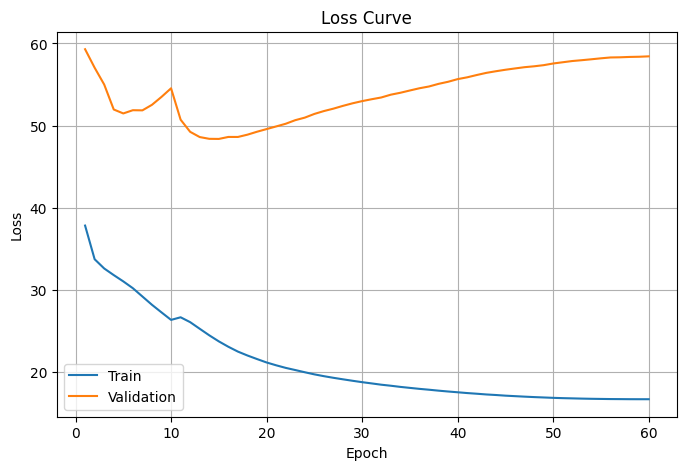

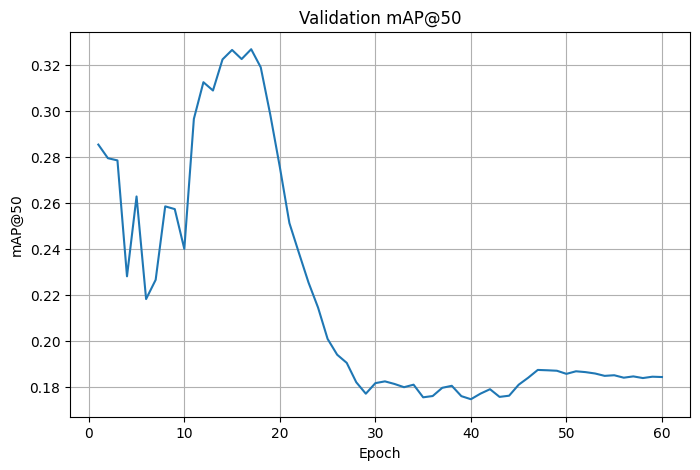

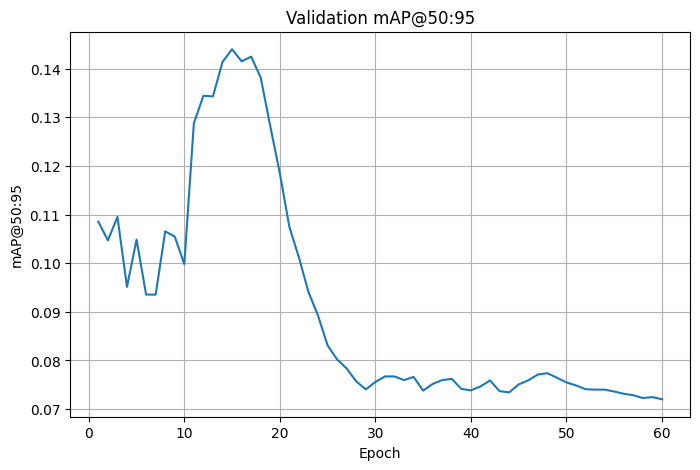

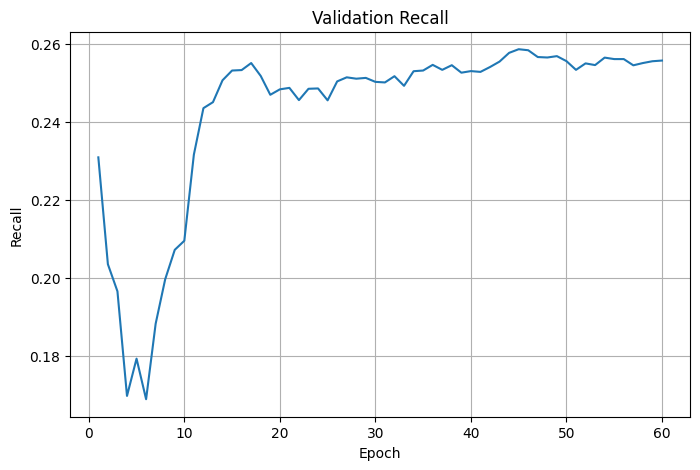

Best mAP@50 = 0.3269489109516144


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import os

history_file = "/content/drive/MyDrive/LLVIP_RUN/history_20260526_231536.json"

with open(history_file, "r") as f:
    history = json.load(f)

print("Loaded keys:")
print(history.keys())

epochs = np.arange(
    1,
    len(history["train_losses"]) + 1
)

# ==========================
# LOSS
# ==========================
plt.figure(figsize=(8,5))
plt.plot(epochs, history["train_losses"], label="Train")
plt.plot(epochs, history["val_losses"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# ==========================
# MAP50
# ==========================
plt.figure(figsize=(8,5))
plt.plot(epochs, history["val_map50s"])
plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.title("Validation mAP@50")
plt.grid(True)
plt.show()

# ==========================
# MAP50:95
# ==========================
plt.figure(figsize=(8,5))
plt.plot(epochs, history["val_map5095s"])
plt.xlabel("Epoch")
plt.ylabel("mAP@50:95")
plt.title("Validation mAP@50:95")
plt.grid(True)
plt.show()

# ==========================
# RECALL
# ==========================
plt.figure(figsize=(8,5))
plt.plot(epochs, history["val_precisions"])
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Validation Recall")
plt.grid(True)
plt.show()

print("Best mAP@50 =", history["best_map50"])

## Test Loop and Visualizations

In [ ]:
# LOAD BEST MODEL
device = "cuda" if torch.cuda.is_available() else "cpu"

model = FullModel(
    num_classes=1,
    use_ir=True
).to(device)

ckpt = torch.load(
    "/content/drive/MyDrive/LLVIP_RUN/checkpoints_20260526_231536/best.pth",  # change if needed
    map_location=device
)

model.load_state_dict(
    ckpt["model_state_dict"]
)

model.eval()

print("✅ Best model loaded")
print("Epoch:", ckpt["epoch"] + 1)
print("AP50:", ckpt["map50"])
print("AP50:95:", ckpt["map5095"])

✅ Best model loaded
Epoch: 17
AP50: 0.3269489109516144
AP50:95: 0.14247213304042816


In [ ]:
# ==========================================
# TEST LOOP
# ==========================================

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm import tqdm

metric = MeanAveragePrecision()

model.eval()

test_loss = 0.0

with torch.no_grad():

    for batch in tqdm(test_loader, desc="Testing"):

        if batch is None:
            continue

        rgb, ir, targets = batch

        rgb = rgb.to(device, non_blocking=True)
        ir  = ir.to(device, non_blocking=True)

        targets = [t.to(device) for t in targets]

        with torch.amp.autocast(
            "cuda",
            enabled=(device == "cuda")
        ):

            preds = model(rgb, ir)

            loss, _, _ = detection_loss_yolov8(
                preds,
                targets
            )

        if not torch.isfinite(loss):
            continue

        test_loss += loss.item()

        metric.update(
            preds_to_map_format(preds),
            targets_to_map_format(targets)
        )

test_loss /= max(1, len(test_loader))

results = metric.compute()

test_map50 = results["map_50"].item()
test_map5095 = results["map"].item()
test_recall = results["mar_100"].item()

Testing: 100%|██████████| 433/433 [00:43<00:00, 10.06it/s]


In [ ]:
# ==========================================
# RESULTS
# ==========================================

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"mAP@50        : {test_map50:.4f}")
print(f"mAP@50:95     : {test_map5095:.4f}")
print(f"Recall@100    : {test_recall:.4f}")

print("="*60)

# Save results

import json
import os

os.makedirs("test_results", exist_ok=True)

results_dict = {
    "test_loss": float(test_loss),
    "map50": float(test_map50),
    "map5095": float(test_map5095),
    "recall": float(test_recall)
}

with open("test_results/results.json", "w") as f:
    json.dump(results_dict, f, indent=4)

print("✅ Results saved to test_results/results.json")


FINAL TEST RESULTS
Test Loss     : 36.7453
mAP@50        : 0.8157
mAP@50:95     : 0.4532
Recall@100    : 0.5339
✅ Results saved to test_results/results.json


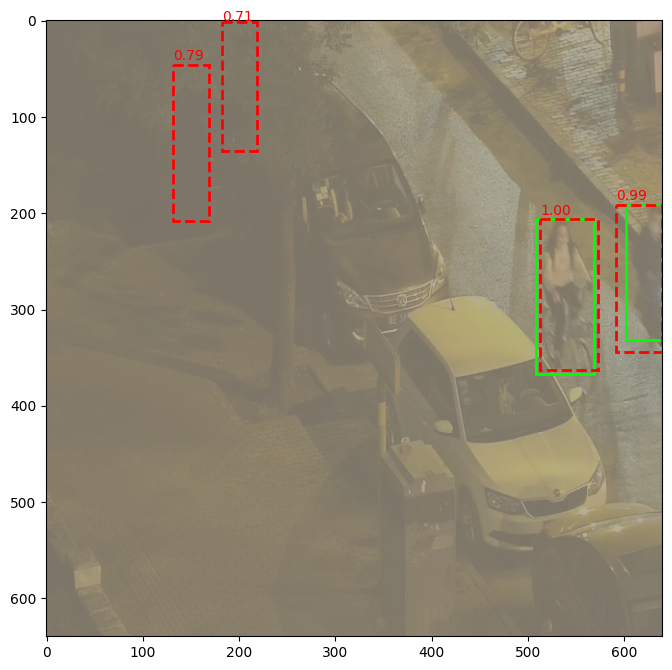

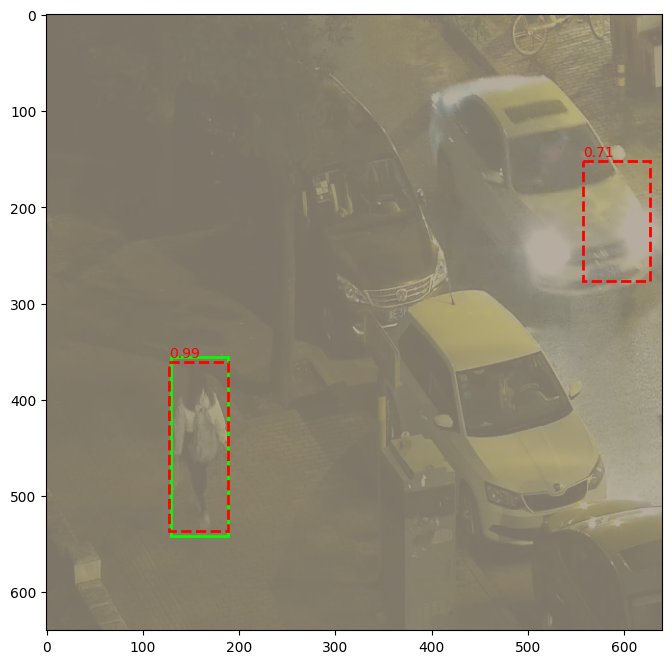

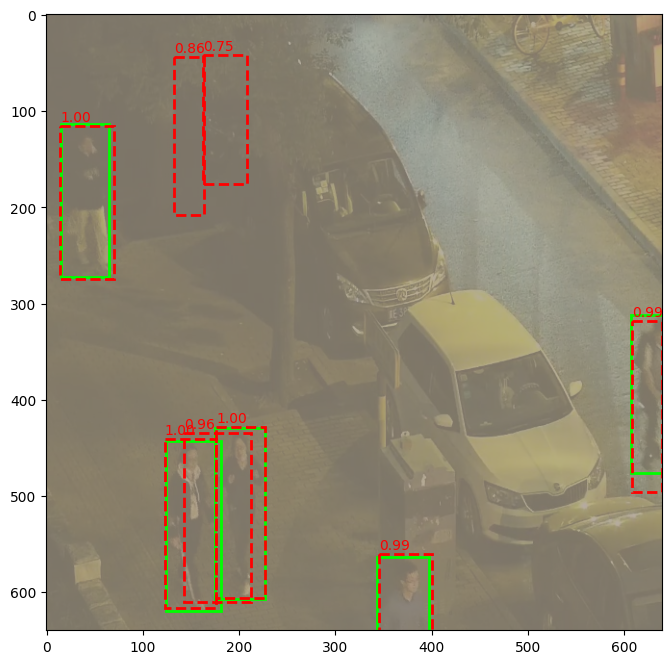

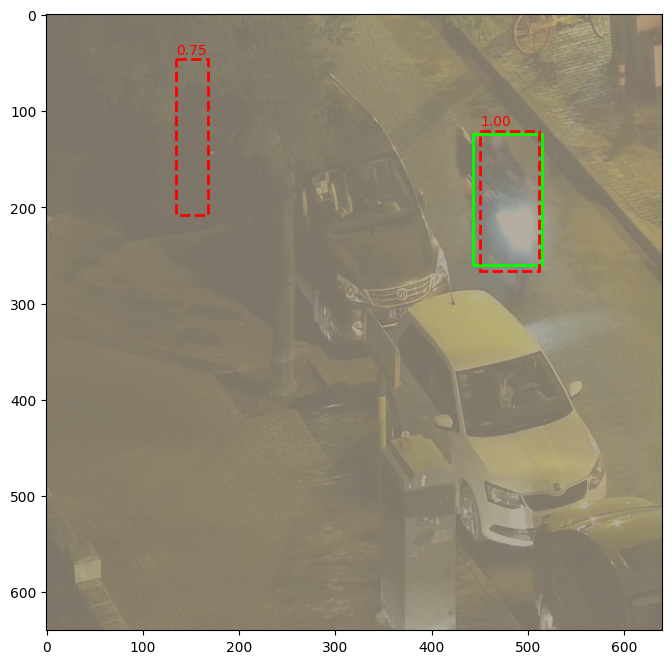

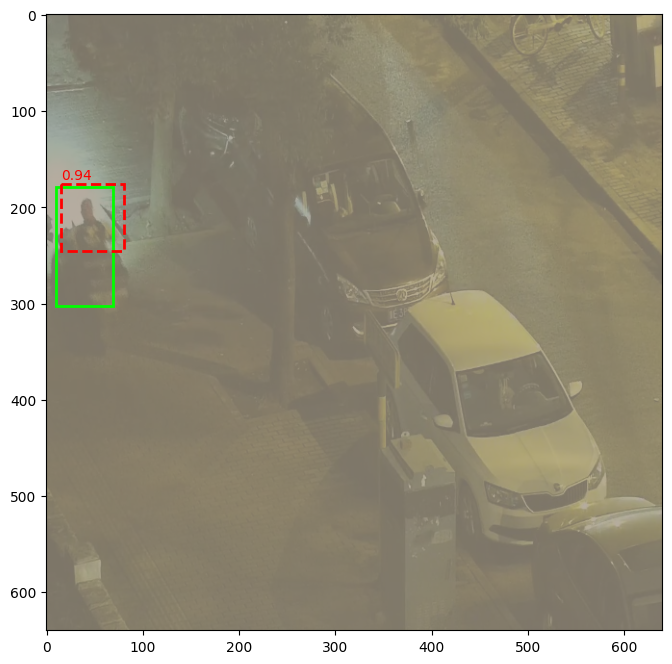

Displayed 5 test images.


In [ ]:
shown = 0
stop_vis = False

with torch.no_grad():

    for batch in test_loader:

        if batch is None:
            continue

        rgb, ir, targets = batch

        rgb_gpu = rgb.to(device)
        ir_gpu  = ir.to(device)

        preds = model(rgb_gpu, ir_gpu)
        preds = preds_to_map_format(preds)

        for i in range(len(rgb)):

            # =====================
            # YOUR VISUALIZATION CODE
            # =====================

            img = rgb[i].permute(1, 2, 0).cpu().numpy()

            mean = [0.485, 0.456, 0.406]
            std  = [0.229, 0.224, 0.225]

            img = img * std + mean
            img = img.clip(0, 1)

            fig, ax = plt.subplots(figsize=(8, 8))
            ax.imshow(img)

            H, W = img.shape[:2]

            # Ground Truth
            labels = targets[i].cpu().numpy()

            for row in labels:

                cls, xc, yc, bw, bh = row

                x1 = (xc - bw/2) * W
                y1 = (yc - bh/2) * H
                x2 = (xc + bw/2) * W
                y2 = (yc + bh/2) * H

                ax.add_patch(
                    patches.Rectangle(
                        (x1, y1),
                        x2 - x1,
                        y2 - y1,
                        fill=False,
                        linewidth=2,
                        edgecolor="lime"
                    )
                )

            # Predictions
            pred_boxes = preds[i]["boxes"].cpu().numpy()
            pred_scores = preds[i]["scores"].cpu().numpy()

            for box, score in zip(pred_boxes, pred_scores):

                if score < 0.7:
                    continue

                x1, y1, x2, y2 = box

                if max(box) <= 1.5:
                    x1 *= W
                    y1 *= H
                    x2 *= W
                    y2 *= H

                ax.add_patch(
                    patches.Rectangle(
                        (x1, y1),
                        x2 - x1,
                        y2 - y1,
                        fill=False,
                        linewidth=2,
                        linestyle="--",
                        edgecolor="red"
                    )
                )

                ax.text(
                    x1,
                    max(0, y1 - 5),
                    f"{score:.2f}",
                    fontsize=10,
                    color="red"
                )

            plt.show()

            shown += 1

            if shown >= 5:
                stop_vis = True
                break

        if stop_vis:
            break

print(f"Displayed {shown} test images.")